# Simulation — Ideal Conditions

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Main misspecification simulation

Simulate data from the ideal population model and fit the analysis CFA model across the sample-size grid in SEQ. This yields the reference sampling distribution of fit indices under the correctly specified condition.

In [ ]:

popmodel_ideal <- cache_or_run("popmodel_ideal", {
  sim(
    NULL,
    n = SEQ1,              # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
    analyzemodel,
    generate = popmodel,
    std.lv = TRUE,
    lavaanfun = "cfa",
    seed = SEED,
    multicore = TRUE
)
})


Simulate data from the alternative population model and fit the same analysis CFA model across the same sample-size grid. This creates the sampling distribution of fit indices under misspecification, which is later contrasted with the reference condition to evaluate power.

In [ ]:

h1model_ideal <- cache_or_run("h1model_ideal", {
  sim(
    NULL,
    n = SEQ1,              # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
    analyzemodel,
    generate = h1model,
    std.lv = TRUE,
    lavaanfun = "cfa",
    seed = SEED,
    multicore = TRUE
)
})


## Main misspecification outputs

### Power curves for fit indices

The following figure summarizes power for rejecting the misspecified condition using the selected fit indices. In `simsem`, `plotPowerFit()` visualizes how this power changes as a function of sample size, using the alternative-model results against the reference-model results and the chosen significance level ($\alpha$) to determine the power at each sample size. The curves show the probability of correctly rejecting the null hypothesis of good fit (i.e., accepting the misspecified model) across different sample sizes, which helps to identify the sample size needed to achieve a desired level of power (e.g., 80%) for detecting misspecification using fit indices.

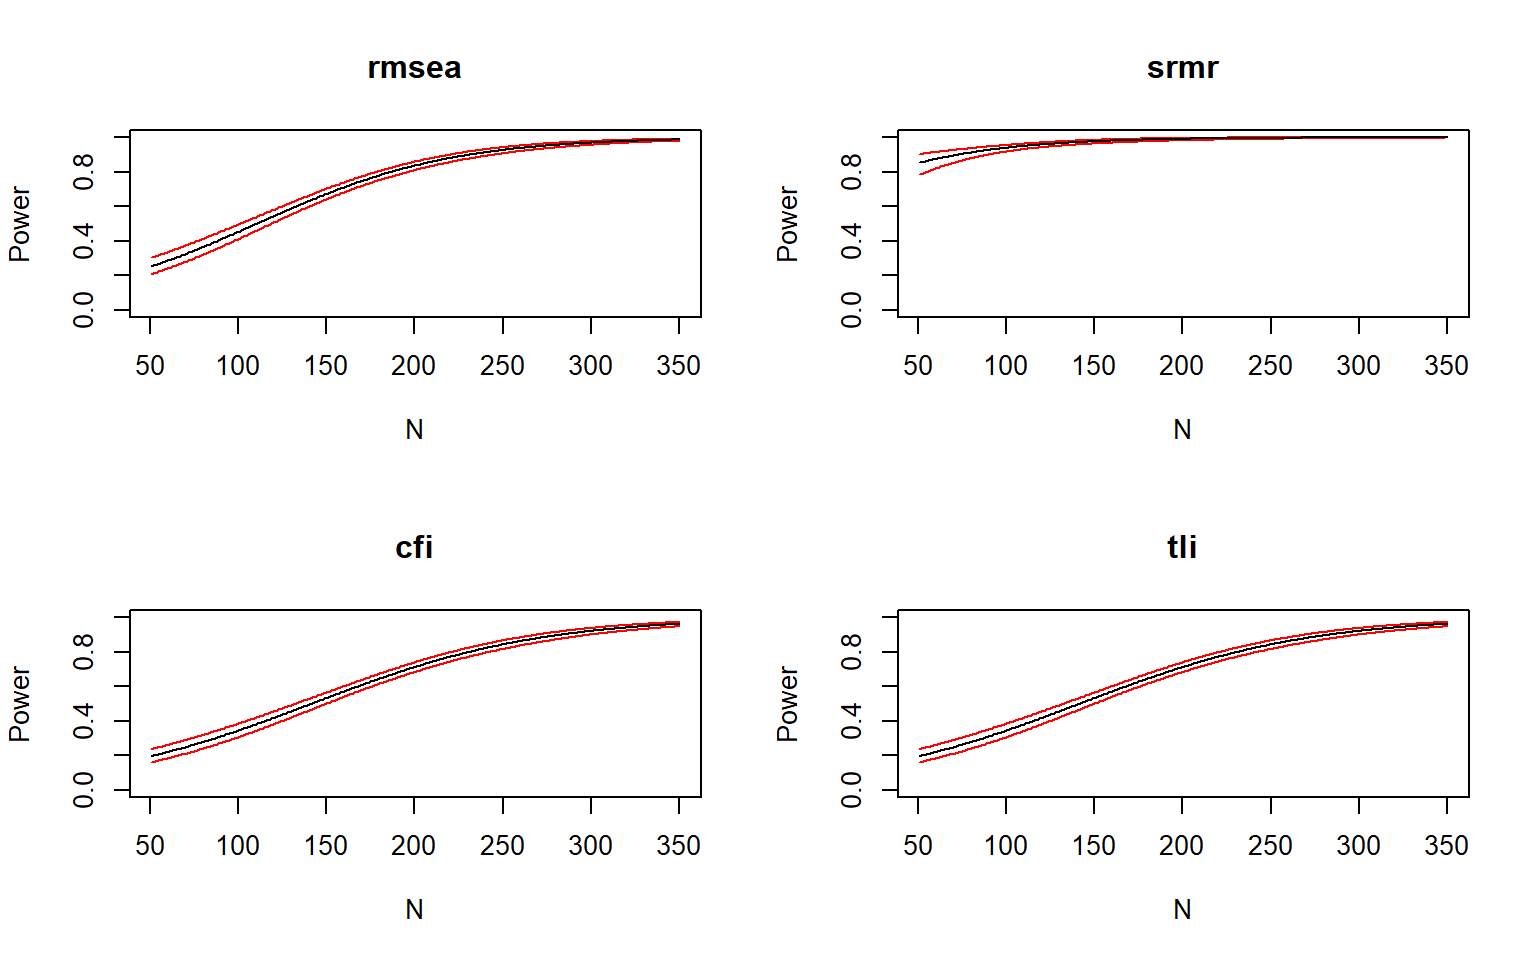

In [ ]:

plotPowerFit(
    h1model_ideal,
    popmodel_ideal,
    alpha = ALPHA,
    usedFit = FITS
)


The following figure summarizes empirical fit-index distributions for the misspecified condition against the reference condition across the sample-size sequence in N: `usedFit` restricts the display to the selected indices in `FITS` and `logistic = FALSE` requests the raw overlaid scatterplot with cutoff lines instead of logistic-smoothed power curves.

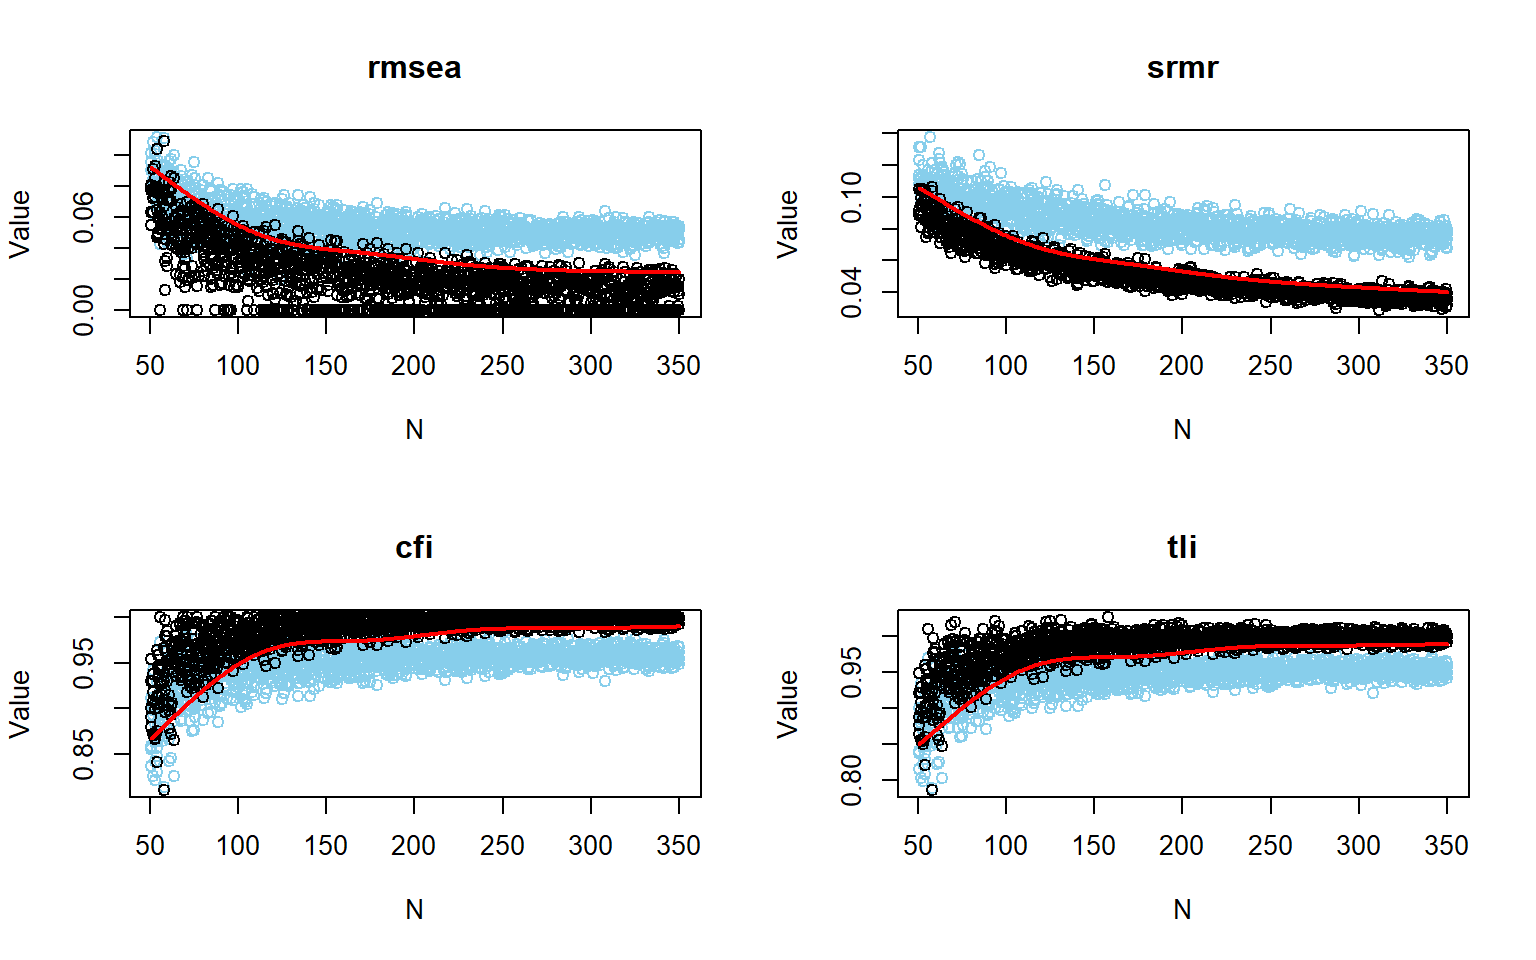

In [ ]:

plotPowerFit(
    h1model_ideal,
    popmodel_ideal,
    alpha = ALPHA,
    usedFit = FITS,
    logistic = FALSE
)


### Power cutoff values for fit indices

This chunk estimates, at $N = 231$, the empirical power to reject the misspecified model using selected fit indices and, in parallel, derives the corresponding cutoff values from the null model under the same ($\alpha$) level and sample size. In this setup, power is the proportion of replications in which the misspecified model shows worse fit than the cutoff implied by the null-model sampling distribution, which aligns with the general SEM view of power as the probability of rejecting a false null hypothesis ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

The logic is straightforward: `getPowerFit()` evaluates how often the alternative model would be rejected, whereas `getCutoff()` obtains index-specific critical values from the null model. Using empirically derived cutoffs is preferable to generic rules of thumb when the goal is to tailor the decision criterion to the specific model, sample size, and analysis conditions ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

In [ ]:

# Estimate power for rejecting the misspecified model (h1model_ideal)
# using fit-index cutoffs implied by the null model at alpha = ALPHA and N = 231.
power_ideal <- getPowerFit(
    h1model_ideal,
    nullObject = popmodel_ideal,
    alpha = ALPHA,
    nVal = 231,
    usedFit = FITS
)

# Derive empirical cutoff values for the selected fit indices
# from the null-model sampling distribution under the same conditions.
cutoff_ideal <- getCutoff(
    popmodel_ideal,
    alpha = ALPHA,
    nVal = 231,
    usedFit = FITS
)

# Combine power and cutoff values into a compact summary table.
power_cutoff_ideal <- rbind(
    "Power" = as.numeric(power_ideal),
    "Cutoff" = as.numeric(cutoff_ideal[1, ])
)

colnames(power_cutoff_ideal) <- toupper(names(power_ideal)) # Standardize column names for presentation.


knitr::kable(power_cutoff_ideal, digits = 3, align = "c") # Print the table.


            RMSEA   SRMR     CFI     TLI
  -------- ------- ------- ------- -------
  Power     0.900   0.995   0.801   0.801
  Cutoff    0.039   0.058   0.965   0.961


### Tradidional cutoff values for fit indices

This chunk plots the simulated fit-index distributions across sample sizes to inspect how often the misspecified model would be rejected using traditional cutoff values. It uses `plotPowerFit()` with fixed rule-of-thumb cutoffs, the selected fit indices, and `logistic = FALSE`, so the output is shown as raw simulated points with horizontal cutoff lines rather than logistic power curves ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

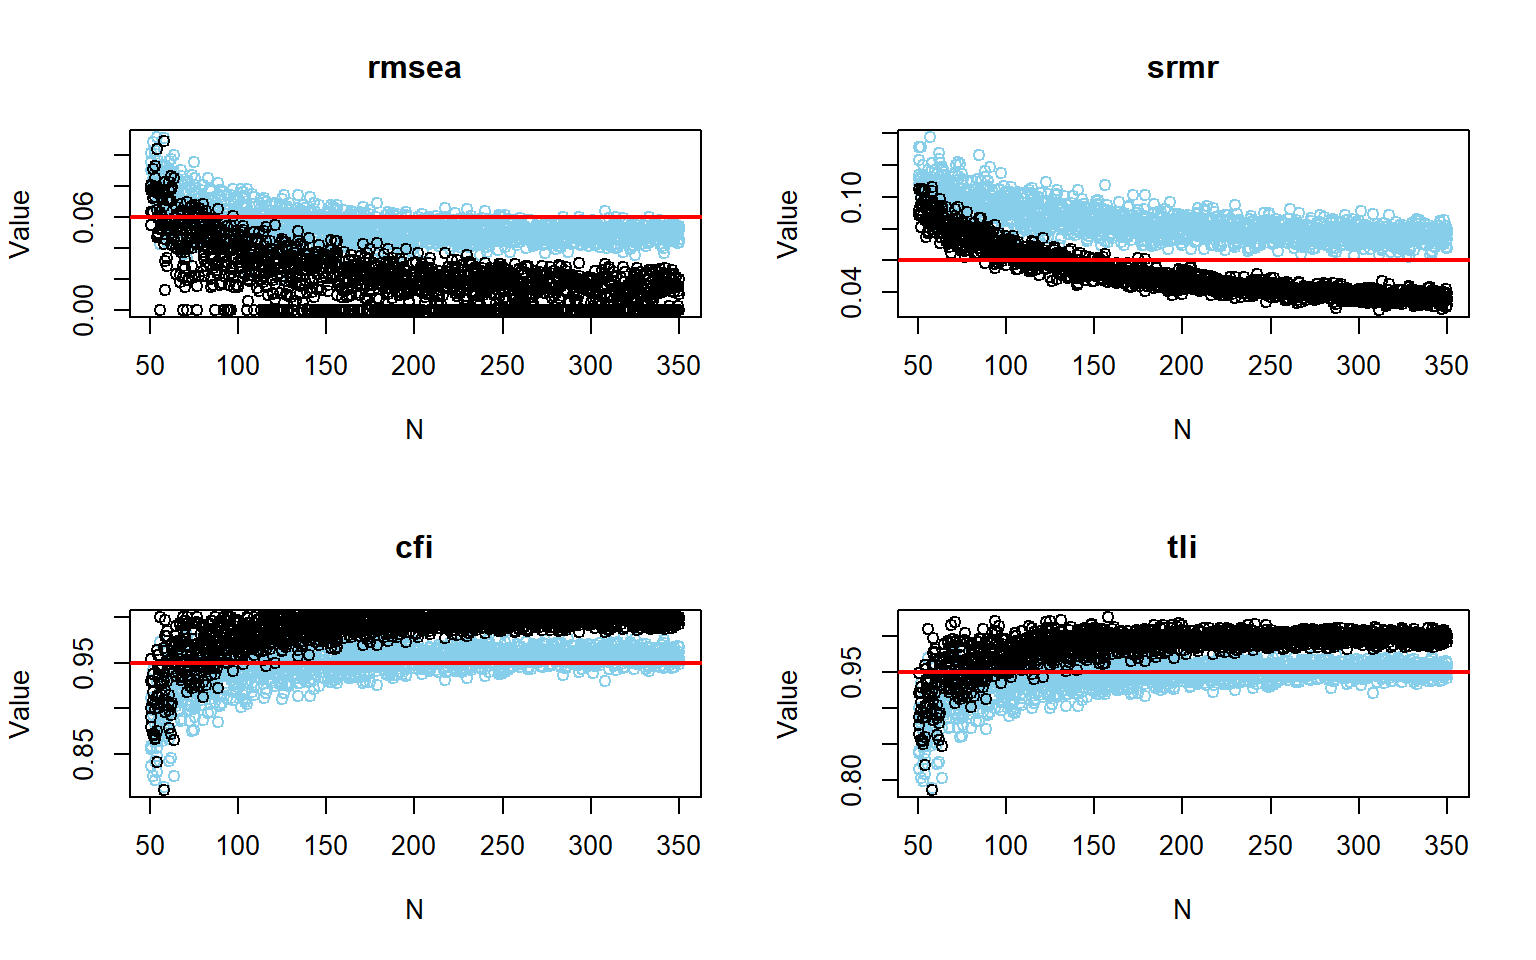

In [ ]:

# Plot fit-index results from the misspecified model across sample sizes.
# The cutoff object applies traditional rule-of-thumb thresholds
# (e.g., RMSEA, SRMR, CFI, and TLI cutoffs) for rejection decisions.
# logistic = FALSE requests the scatterplot-style display of simulated values
# and the cutoff line, instead of a logistic-smoothed power curve

plotPowerFit(
  h1model_ideal,   # Simulated results under the misspecified model
  popmodel_ideal,  # Reference model object used for comparison
  cutoff = RULE_OF_THUMB, # Rule-of-thumb cutoff values for fit indices
  alpha = ALPHA, # Significance level for determining power
  usedFit = FITS, # RMSEA, SRMR, CFI, and TLI fit indices to display
  logistic = FALSE # Display raw simulated points and cutoff lines instead of logistic curves
)


The table below summarizes the empirical power to reject the misspecified model using traditional fit-index cutoffs at $N = 231$ under ideal conditions. This provides a direct comparison of how well the traditional cutoffs perform in terms of power relative to the empirically derived cutoffs from the previous chunk.

In [ ]:

power_trad <- getPowerFit(
    h1model_ideal,
    RULE_OF_THUMB,
    alpha = ALPHA,
    nVal = 231,
    usedFit = FITS
)

# Create horizontal table: Fit Index as column names, Power as single row
power_df <- data.frame(
    "CFI" = round(as.numeric(power_trad["cfi"]), 3),
    "TLI" = round(as.numeric(power_trad["tli"]), 3),
    "RMSEA" = round(as.numeric(power_trad["rmsea"]), 3),
    "SRMR" = power_trad["srmr"],  # Keep as string
    row.names = "Power"
)

knitr::kable(power_df, digits = 3, align = "c", col.names = toupper(names(power_df)))


            CFI     TLI    RMSEA    SRMR
  ------- ------- ------- ------- ---------
  Power    0.381   0.579   0.153   \> 0.98


### Target parameter estimates

Under ideal conditions, the first step is to evaluate parameter recovery rather than focusing on statistical significance alone. In `simsem`, `summaryParam(..., detail = TRUE)` provides detailed recovery diagnostics, including relative bias, relative standard error bias, coverage, and power for testing whether each parameter differs from zero ([Pornprasertmanit et al., 2021](#ref-simsem2021)). Because power in SEM is hypothesis-specific, parameters within the same model may require substantially different sample sizes to reach the same target power ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

In [ ]:

# Compute detailed parameter-recovery results for the fitted model.
param_ideal <- summaryParam(
  h1model_ideal,
  alpha = ALPHA,
  digits = 3,
  detail = TRUE
)

# Keep only the diagnostics used in the discussion.
param_subset <- param_ideal[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]

# Move parameter labels to an explicit first column.
param_subset <- cbind(
  Parameter = rownames(param_subset),
  param_subset,
  row.names = NULL
)

# Build an output-specific display version of the parameter labels.
if (knitr::is_latex_output()) {
  param_subset$Parameter <- gsub(
    "~",
    "\\\\textasciitilde{}",
    param_subset$Parameter,
    fixed = TRUE
  )
  tbl_format <- "latex"
} else if (knitr::is_html_output()) {
  tbl_format <- "html"
} else {
  tbl_format <- "pipe"
}

# Print the table.
knitr::kable(
  param_subset,
  format = tbl_format,
  digits = 3,
  align = c("l", "c", "c", "c", "c"),
  escape = FALSE,
  row.names = FALSE,
  caption = "Parameter estimates under ideal conditions" # REMEMBER ERROR RENDER
)


  Parameter                  Rel Bias   Rel SE Bias   Coverage   Power (Not equal 0)
  ------------------------- ---------- ------------- ---------- ---------------------
  psycho=\~Q5                 -0.003      -0.043       0.947            1.000
  psycho=\~Q6                 -0.005      -0.084       0.937            1.000
  psycho=\~Q7                 -0.004      -0.066       0.940            1.000
  psycho=\~Q11                -0.005      -0.050       0.945            1.000
  psycho=\~Q19                -0.003       0.000       0.953            1.000
  psycho=\~Q26                -0.006      -0.079       0.938            1.000
  physical=\~Q3               -0.011      -0.063       0.947            1.000
  physical=\~Q4               -0.006      -0.066       0.945            1.000
  physical=\~Q10              -0.010      -0.062       0.947            1.000
  physical=\~Q15              0.068       -0.106       0.871            1.000
  physical=\~Q16              -0.011      -0.061       0.941            1.000
  physical=\~Q17              -0.010      -0.090       0.931            1.000
  physical=\~Q18              -0.011      -0.077       0.938            1.000
  social=\~Q20                -0.004      -0.050       0.941            1.000
  social=\~Q21                -0.003      -0.025       0.952            1.000
  social=\~Q22                0.002       -0.048       0.943            1.000
  environment=\~Q8            0.360       -0.090       0.520            0.997
  environment=\~Q9            0.105       -0.051       0.879            0.999
  environment=\~Q12           -0.012      -0.065       0.939            1.000
  environment=\~Q13           -0.010      -0.080       0.942            1.000
  environment=\~Q14           -0.009      -0.045       0.940            1.000
  environment=\~Q23           -0.010      -0.075       0.939            1.000
  environment=\~Q24           -0.006      -0.047       0.947            1.000
  environment=\~Q25           -0.011      -0.059       0.940            1.000
  psycho\~\~physical          0.039       -0.069       0.941            0.751
  psycho\~\~social            -0.002      -0.069       0.935            0.727
  psycho\~\~environment       0.286       -0.122       0.831            0.857
  physical\~\~social          0.046       -0.047       0.944            0.760
  physical\~\~environment     0.239       -0.091       0.875            0.839
  social\~\~environment       0.038       -0.070       0.931            0.736
  Q3\~\~Q4                    0.007       -0.050       0.944            0.775
  Q5\~\~Q5                    -0.012      -0.043       0.944            0.999
  Q6\~\~Q6                    -0.017      -0.039       0.934            1.000
  Q7\~\~Q7                    -0.020      -0.071       0.929            0.993
  Q11\~\~Q11                  -0.014      -0.073       0.926            1.000
  Q19\~\~Q19                  -0.014      -0.050       0.933            1.000
  Q26\~\~Q26                  -0.018      -0.038       0.933            1.000
  Q3\~\~Q3                    -0.012      -0.059       0.935            1.000
  Q4\~\~Q4                    -0.015      -0.040       0.944            1.000
  Q10\~\~Q10                  -0.008      -0.044       0.934            1.000
  Q15\~\~Q15                  0.105       -0.068       0.896            1.000
  Q16\~\~Q16                  -0.011      -0.055       0.934            1.000
  Q17\~\~Q17                  -0.008      -0.084       0.934            0.999
  Q18\~\~Q18                  -0.008      -0.010       0.949            1.000
  Q20\~\~Q20                  -0.004      -0.091       0.943            0.848
  Q21\~\~Q21                  -0.015      -0.042       0.946            0.991
  Q22\~\~Q22                  -0.018      -0.050       0.933            1.000
  Q8\~\~Q8                    0.536       -0.058       0.136            1.000
  Q9\~\~Q9                    0.028       -0.059       0.944            1.000
  Q12\~\~Q12                  -0.001      -0.036       0.943            1.000
  Q13\~\~Q13                  0.004       -0.042       0.936            1.000
  Q14\~\~Q14                  -0.002      -0.085       0.937            1.000
  Q23\~\~Q23                  -0.001      -0.029       0.945            1.000
  Q24\~\~Q24                  -0.013      -0.055       0.937            1.000
  Q25\~\~Q25                  -0.007      -0.058       0.942            1.000

  : Parameter estimates under ideal conditions {.cell
  quarto-postprocess="true"}


The second step is to translate parameter-specific power into a planning quantity. In `simsem`, `getPower()` returns power estimates for model parameters, and `findPower()` identifies the value of the chosen independent variable, here $N$, that first exceeds the target power level; thus, the resulting $N$ should be read as a practical threshold for planning rather than an exact analytical cutoff ([Pornprasertmanit et al., 2021](#ref-simsem2021)). This is useful because SEM sample size requirements should be aligned with the most demanding focal parameters, not with the easiest ones to detect ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).

In [ ]:

# Obtain parameter-specific power estimates across sample sizes.
pow_h1 <- getPower(h1model_ideal, alpha = ALPHA)

# Find the minimum N in the simulated grid that reaches the target power of 0.80.
n_h1 <- findPower(pow_h1, "N", 0.80)

# Convert to a data frame for reporting.
n_df <- data.frame(
  Parameter = names(n_h1),
  N = as.integer(n_h1),
  stringsAsFactors = FALSE
)


Warning in data.frame(Parameter = names(n_h1), N = as.integer(n_h1),
stringsAsFactors = FALSE): NAs introduced by coercion to integer range

  Parameter                   N
  ------------------------- -----
  environment=\~Q8           51
  environment=\~Q9           51
  psycho\~\~physical         200
  psycho\~\~social           212
  psycho\~\~environment      138
  physical\~\~social         198
  physical\~\~environment    148
  social\~\~environment      208
  Q3\~\~Q4                   181
  Q5\~\~Q5                   51
  Q7\~\~Q7                   51
  Q17\~\~Q17                 51
  Q20\~\~Q20                 143
  Q21\~\~Q21                 51


### Recovering the population parameters

Recovery of population parameters is not best strategy in CFA power analyses. The idea is to determine the sample size needed to accurately estimate the population parameters (e.g., factor loadings $\neq 0$) with a certain level of precision. This can be done by simulating data under different models and evaluating how well the analysis model recovers the population parameters.

But this strategy its not pratical because uselly we don’t need an large sample size to recover the loadings \> 0, but rather to detect misspecifications (e.g., cross-loadings) that are not present in the population model. Therefore, we can use the power to detect misspecifications as a more relevant criterion for determining the required sample size.

#### Naive model

- Naive model: tau-equivalent loadings (uniform λ per domain) with same reliability as the population model. This is a common but often unrealistic assumption in CFA power analyses.

In [ ]:

naivemodel_ideal <- cache_or_run("naivemodel_ideal", {
  sim(
    NULL,
    n = SEQ1,               # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
    analyzemodel,
    generate = naivemodel,
    std.lv = TRUE,
    lavaanfun = "cfa",
    seed = SEED,
    multicore = TRUE
)
})


This chunk summarizes the parameter-level results of the Monte Carlo simulation by identifying the sample size required to reach $.80$ power for each estimable parameter. In line with simulation-based SEM power analysis, the goal here is not global fit, but parameter recovery under the specified population and analysis models, using the focal parameter requirements to identify the most demanding part of the model ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)). The resulting table focuses on the parameters for which a finite sample size requirement could be determined, which are the most relevant for planning purposes. We also show the fit diagnostics simulated used in this tutorial for the naive model, which are relevant for understanding the misspecification scenario and its implications for power.

In [ ]:

# Compute detailed parameter-recovery results for the fitted model.
param_naive <- summaryParam(
  naivemodel_ideal,
  alpha = ALPHA,
  digits = 3,
  detail = TRUE
)

# Keep only the diagnostics used in the discussion.
param_subset <- as.data.frame(
  param_naive[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]
)

# Compute parameter-level power across the simulated values of N.
pow_naive <- getPower(naivemodel_ideal, alpha = ALPHA)

# Extract the minimum N that reaches the target power of .80 for each parameter.
n_naive <- findPower(pow_naive, "N", 0.80)

# Add required N to the subset.
param_subset$N <- as.integer(n_naive[rownames(param_subset)])


  Parameter                  Rel Bias   Rel SE Bias   Coverage   Power (Not equal 0)   Required N
  ------------------------- ---------- ------------- ---------- --------------------- ------------
  psycho\~\~physical          0.140       -0.944       0.913            0.793             180
  psycho\~\~social            -0.009      -0.137       0.922            0.780             186
  psycho\~\~environment       -0.003      -0.089       0.931            0.817             164
  physical\~\~social          0.331       -0.971       0.924            0.775             192
  physical\~\~environment     0.141       -0.932       0.929            0.793             178
  social\~\~environment       -0.014      -0.123       0.928            0.780             184
  Q3\~\~Q4                    -0.013      -0.130       0.932            0.845             143


#### Optimal model

- Optimal model: tau-equivalent loadings (uniform λ per domain) with same reliability as the population model, but with higher loadings to match the population reliability. This represents an idealized scenario where the analysis model is correctly specified in terms of reliability, but still assumes tau-equivalence.

In [ ]:

optmodel_ideal <- cache_or_run("optmodel_ideal", {
  sim(
    NULL,
    n = SEQ1,               # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
    analyzemodel,
    generate = optmodel,
    std.lv = TRUE,
    lavaanfun = "cfa",
    seed = SEED,
    multicore = TRUE
)
})


This chunk computes parameter-level power for the optimal model and extracts the minimum sample size $N$ required for each parameter to reach $.80$ power at the chosen $\alpha$ level. In Monte Carlo SEM power analysis, this step helps identify which parameters are more or less demanding in terms of sample size under the assumed data-generating and analysis conditions ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)). The resulting table focuses on the parameters for which a finite sample size requirement could be determined, which are the most relevant for planning purposes. We also show the fit diagnostics simulated used in this tutorial for the naive model, which are relevant for understanding the misspecification scenario and its implications for power.

In [ ]:

# Compute detailed parameter-recovery results for the fitted model.
param_opt <- summaryParam(
  optmodel_ideal,
  alpha = ALPHA,
  digits = 3,
  detail = TRUE
)

# Keep only the diagnostics used in the discussion.
param_subset <- as.data.frame(
  param_opt[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]
)

# Compute parameter-level power across the simulated values of N.
pow_opt <- getPower(optmodel_ideal, alpha = ALPHA)

# Extract the minimum N that reaches the target power of .80 for each parameter.
n_opt <- findPower(pow_opt, "N", 0.80)

# Add required N to the subset.
param_subset$N <- as.integer(n_opt[rownames(param_subset)])


  Parameter    Rel Bias   Rel SE Bias   Coverage   Power (Not equal 0)   Required N
  ----------- ---------- ------------- ---------- --------------------- ------------
  Q3\~\~Q4      -0.008      -0.082       0.934            0.85              139


### Misspecification and population sensitivity

#### Naive model

These chunks evaluate fit-index-based power for the naive population model across sample sizes and then extract the corresponding power and empirical cutoff values at $N = 330$. In simulation-based SEM power analysis, this workflow is useful when the goal is to assess how well different fit indices discriminate between a better-fitting and a worse-fitting model as sample size increases ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

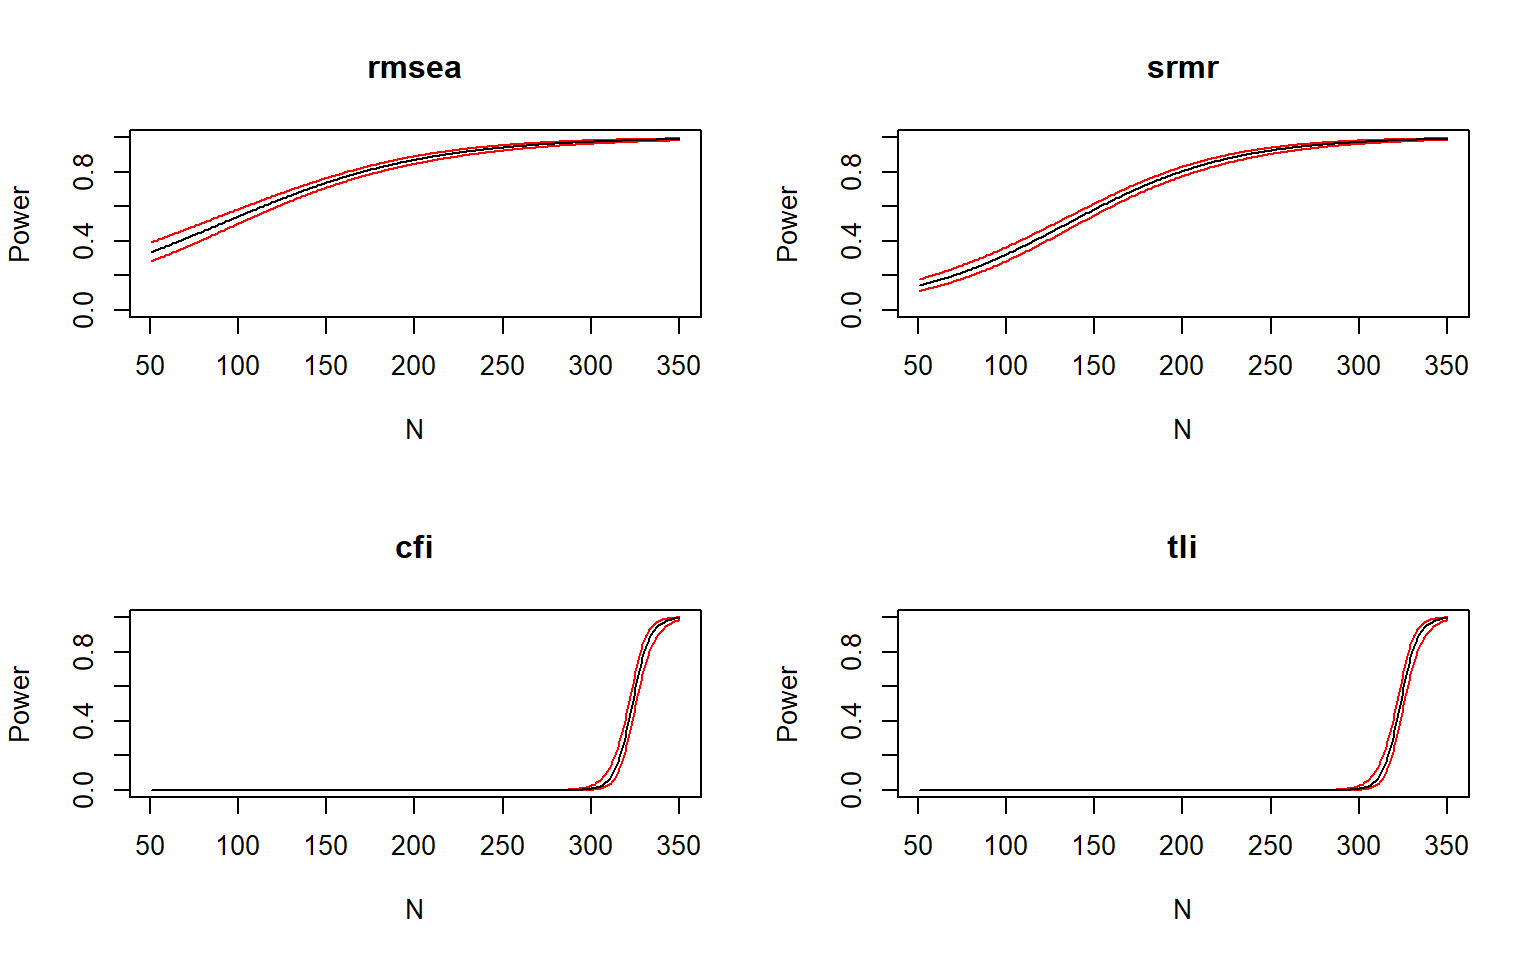

In [ ]:

# Plot fit-index-based power as a function of N.
# With logistic = TRUE (default), simsem smooths the reject/retain decisions
# across sample size using logistic regression, yielding continuous power curves
# for each fit index.
plotPowerFit(
  h1model_ideal,
  naivemodel_ideal,
  alpha = ALPHA,
  usedFit = FITS
)


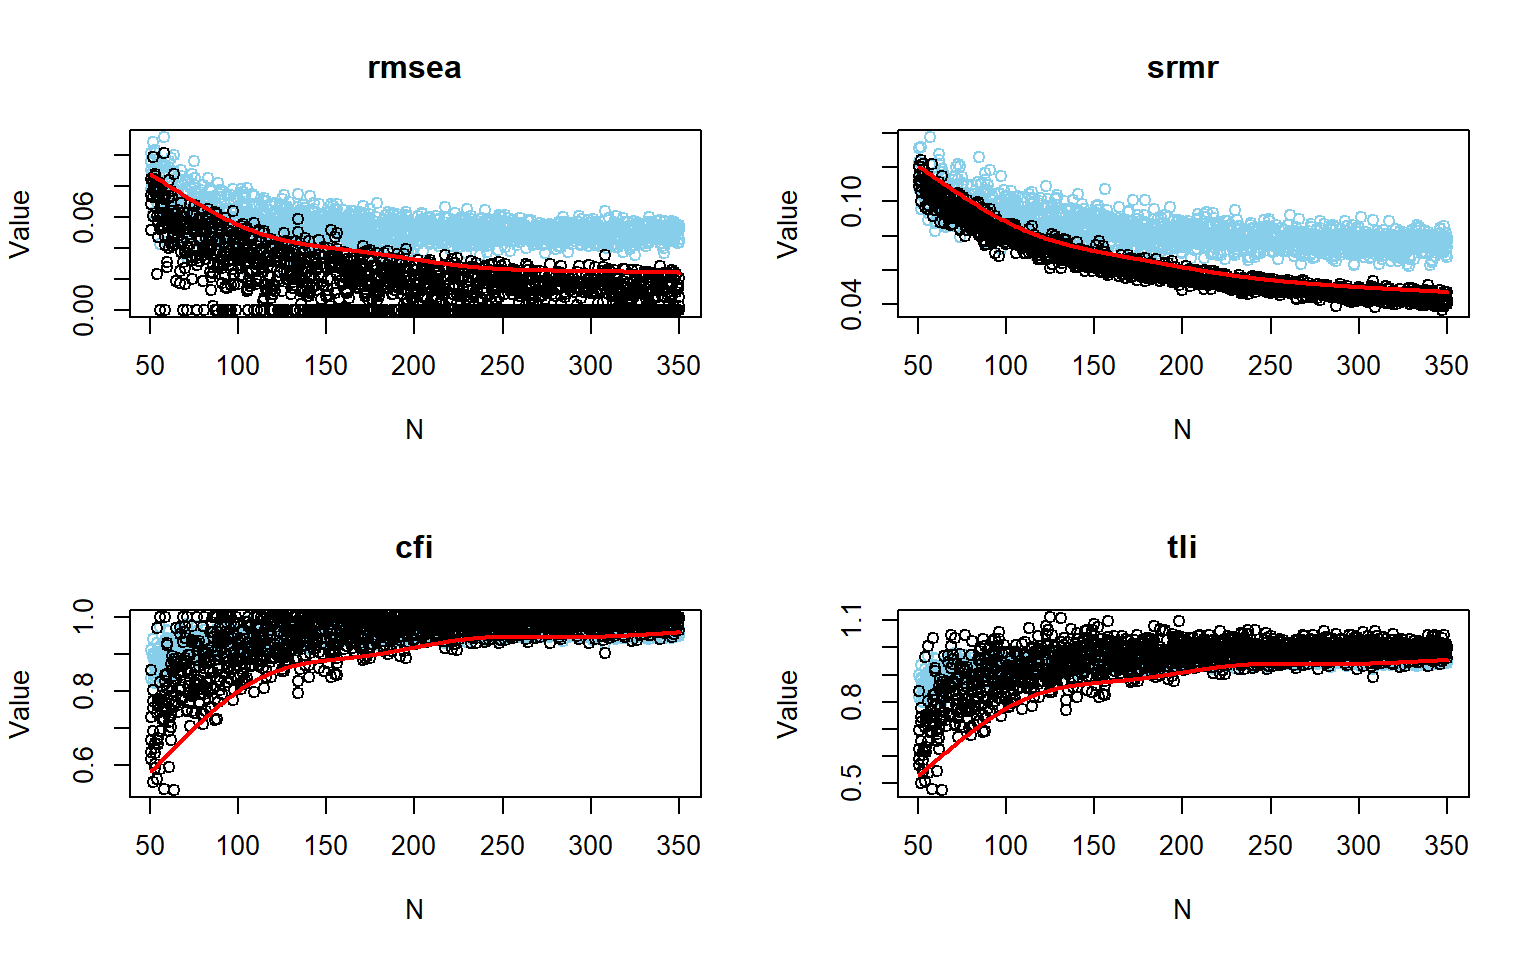

In [ ]:

# Plot the raw fit-index distributions over N without logistic smoothing.
# This version is useful to inspect the empirical separation between the null
# and alternative model results before smoothing them into power curves.
plotPowerFit(
  h1model_ideal,
  naivemodel_ideal,
  alpha = ALPHA,
  usedFit = FITS,
  logistic = FALSE
)


The next chunk computes, at $N = 330$, the estimated power for each fit index and the empirical cutoff implied by the null-model sampling distribution at the chosen $\alpha$ level. This provides a direct summary of how stringent each index is and whether the selected sample size is sufficient under the naive scenario.

In [ ]:

# Estimate the power to reject the misspecified model at N = 330 for each fit index.
power_naive <- getPowerFit(
  h1model_ideal,
  nullObject = naivemodel_ideal,
  alpha = ALPHA,
  nVal = 330,
  usedFit = FITS
)

# Derive empirical fit-index cutoffs from the null model at the same alpha level.
cutoff_naive <- getCutoff(
  naivemodel_ideal,
  alpha = ALPHA,
  nVal = 330,
  usedFit = FITS
)

# Combine power and cutoff values into a compact summary table.
power_cutoff_naive <- rbind(
  "Power" = as.numeric(power_naive),
  "Cutoff" = as.numeric(cutoff_naive[1, ])
)
colnames(power_cutoff_naive) <- toupper(names(power_naive))

# Print the final table.
knitr::kable(power_cutoff_naive, digits = 3, align = "c")


            RMSEA   SRMR     CFI     TLI
  -------- ------- ------- ------- -------
  Power     0.984   0.986   0.801   0.801
  Cutoff    0.022   0.047   0.964   0.959


#### Optimal model

The code below evaluates fit-index-based power under the optimal population model. In this setup, `plotPowerFit()` visualizes how the probability of rejecting inadequate fit changes as sample size varies, using fit-index cutoffs derived from the reference model; this follows the simulation-based logic implemented in `simsem` for power assessment via fit indices rather than single-parameter tests ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

When `logistic = TRUE` (default), the plotted curves are smoothed using logistic regression over the varying sample sizes, which is useful when $N$ changes continuously across replications ([Pornprasertmanit et al., 2021](#ref-simsem2021)). When `logistic = FALSE`, the function shows the raw simulated relationship between sample size and the fit indices, overlaid with the cutoff boundary, which is more descriptive and less model-smoothed ([Pornprasertmanit et al., 2021](#ref-simsem2021)).

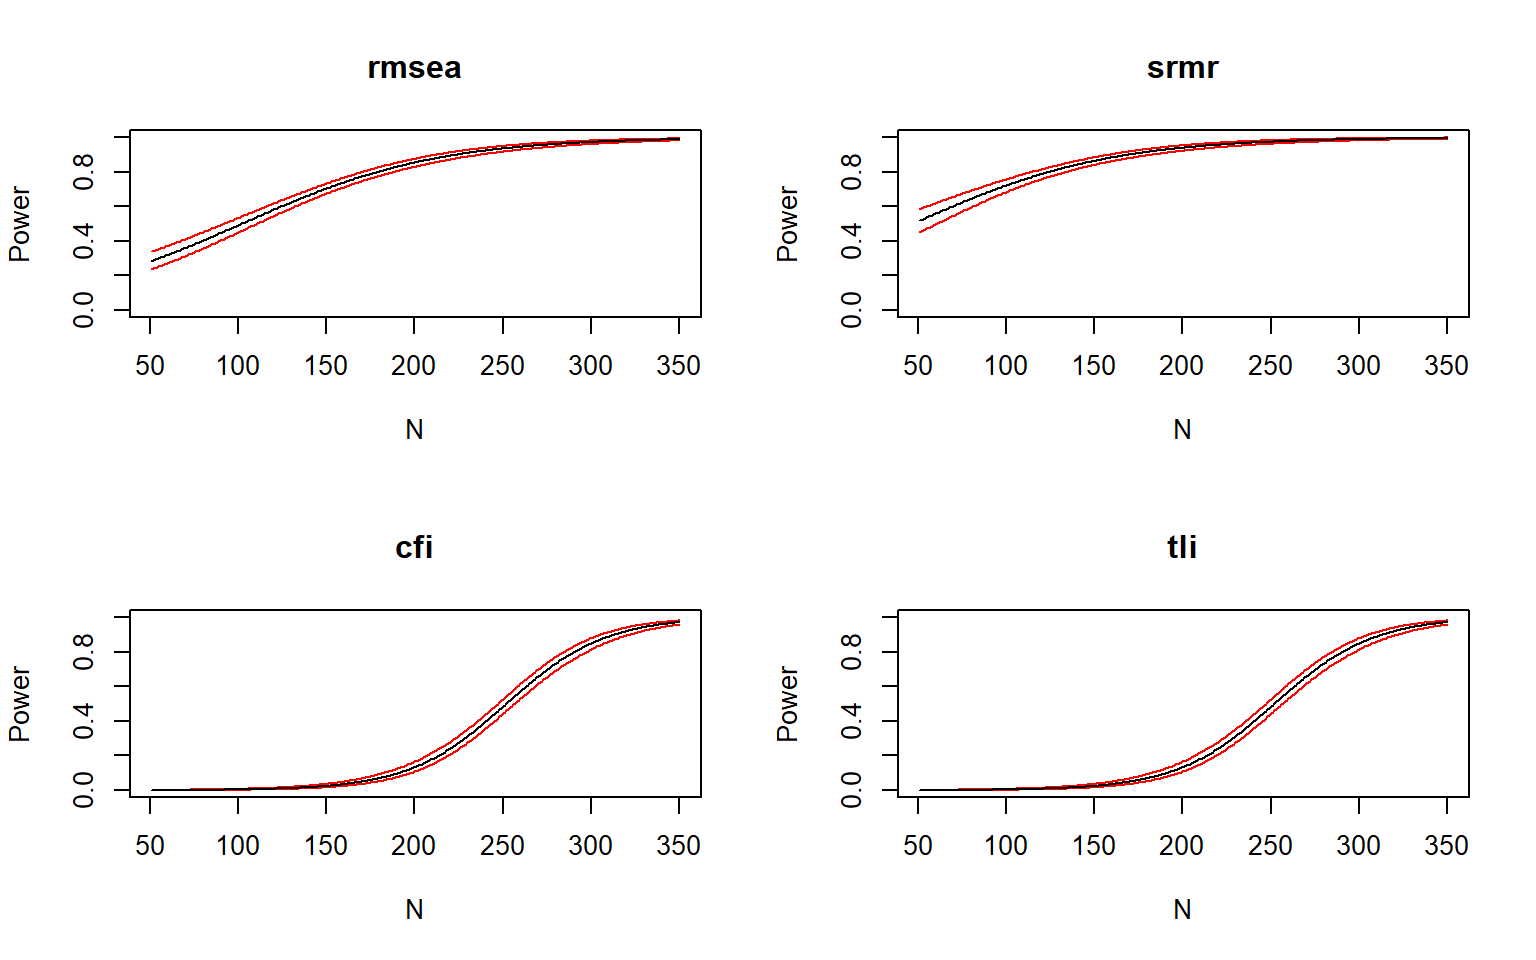

In [ ]:

# Plots power as a function of N for the selected fit indices.
# The null/reference object provides the cutoff distribution.
# With the default logistic = TRUE, the curves are smoothed.

plotPowerFit(
  h1model_ideal,
  optmodel_ideal,
  alpha = ALPHA,
  usedFit = FITS
)


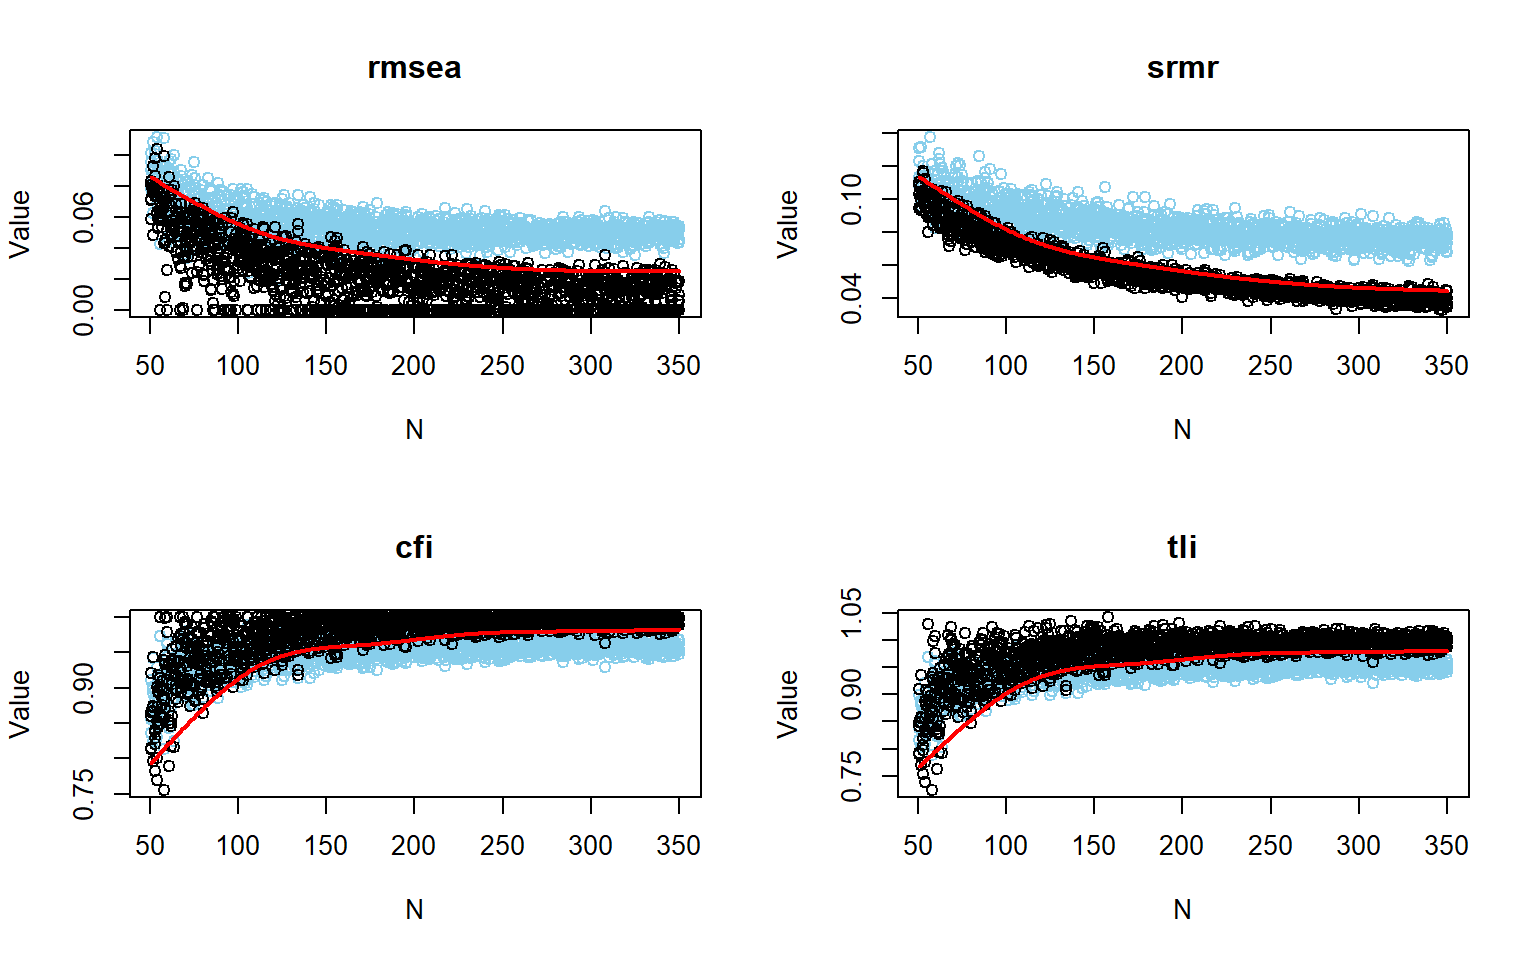

In [ ]:

# Repeats the previous plot without logistic smoothing.
# This version emphasizes the raw simulated fit-index patterns across N.

plotPowerFit(
  h1model_ideal,
  optmodel_ideal,
  alpha = ALPHA,
  usedFit = FITS,
  logistic = FALSE
)


The next chunk computes, at a fixed sample size $N = 291$, the estimated power for each selected fit index and the corresponding cutoff values obtained from the optimal reference model. In `simsem`, `getPowerFit()` returns the probability that each index correctly flags worse fit at the requested $N$, whereas `getCutoff()` returns the index-specific decision thresholds associated with the chosen $\alpha$ level ([Pornprasertmanit et al., 2021](#ref-simsem2021)).

In [ ]:

# Power at the target sample size for each fit index.
power_opt <- getPowerFit(
  h1model_ideal,
  nullObject = optmodel_ideal,
  alpha = ALPHA,
  nVal = 291,
  usedFit = FITS
)

# Index-specific cutoffs derived from the reference model at the same N.
cutoff_opt <- getCutoff(
  optmodel_ideal,
  alpha = ALPHA,
  nVal = 291,
  usedFit = FITS
)

# Combines power and cutoff values into a compact display table.
power_cutoff_opt <- rbind(
  "Power" = as.numeric(power_opt),
  "Cutoff" = as.numeric(cutoff_opt[1, ])
)
colnames(power_cutoff_opt) <- toupper(names(power_opt))

knitr::kable(power_cutoff_opt, digits = 3, align = "c")


            RMSEA   SRMR     CFI     TLI
  -------- ------- ------- ------- -------
  Power     0.968   0.988   0.805   0.805
  Cutoff    0.028   0.051   0.970   0.966


Jobst, L. J., Bader, M., & Moshagen, M. (2023). A tutorial on assessing statistical power and determining sample size for structural equation models. *Psychological Methods*, *28*(1), 207–221. <https://doi.org/10.1037/met0000423>

Moshagen, M., & Bader, M. (2024). <span class="nocase">semPower</span>: General power analysis for structural equation models. *Behavior Research Methods*, *56*(4), 2901–2922. <https://doi.org/10.3758/s13428-023-02254-7>

Pornprasertmanit, S., Miller, P., Schoemann, A., & Jorgensen, T. D. (2021). *Simsem: SIMulated Structural Equation Modeling*. <https://CRAN.R-project.org/package=simsem>